# 05 – LSTM Forecasting Model

## Objective

This notebook develops a Long Short-Term Memory (LSTM) neural network for forecasting the weekly EUR/USD closing exchange rate.

Unlike ARIMA and Random Forest, the LSTM model is capable of learning nonlinear temporal dependencies directly from sequential historical observations, making it well suited for financial time series forecasting.

The forecasting performance will be evaluated using the same chronological train-test split and evaluation metrics (MAE, RMSE, and MAPE) to enable a fair comparison with the previous models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
print(tf.__version__)

2.21.0


## Loading the Model-Ready Dataset

The corrected model-ready dataset is loaded for LSTM training. This dataset contains only historical predictor variables together with the one-week-ahead target variable, which helps prevent look-ahead bias.

In [3]:
df = pd.read_csv(
    "../data/processed/eur_weekly_model_ready_v2.csv",
    parse_dates=["Date"]
)

df.head()

,Date,Price,Open,High,Low,Change %,Lag_1,Lag_2,Lag_3,MA_5,MA_10,MA_20,Volatility_5,Target
0,2000-10-01,0.8685,0.8797,0.8887,0.8710,0.89,0.8839,0.8761,0.8536,0.87592,0.89223,0.916385,0.017512,0.8563
1,2000-10-08,0.8563,0.8843,0.8861,0.8662,-1.74,0.8685,0.8839,0.8761,0.86966,0.88674,0.914940,0.011352,0.8421
2,2000-10-15,0.8421,0.8693,0.8768,0.8530,-1.40,0.8563,0.8685,0.8839,0.86768,0.88156,0.911195,0.012869,0.8396
3,2000-10-22,0.8396,0.8548,0.8578,0.8326,-1.66,0.8421,0.8563,0.8685,0.86538,0.87552,0.905975,0.016523,0.8667
4,2000-10-29,0.8667,0.8414,0.8443,0.8227,-0.30,0.8396,0.8421,0.8563,0.85808,0.86883,0.900295,0.018542,0.8604


## Preparing Features and Target Variable

The predictor variables (features) and the target variable are separated before scaling and sequence generation.

The **Target** column is selected as the prediction target because it represents the EUR/USD closing exchange rate one week ahead.

The **Date** and **Price** columns are excluded from the predictor variables. The Date column does not provide useful numerical information for the neural network, while the Price column is omitted because the future value is already represented by the Target variable.

In [4]:
# Target variable
y = df["Target"]

# Feature variables
X = df.drop(columns=["Date", "Price", "Target"])

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Open', 'High', 'Low', 'Change %', 'Lag_1', 'Lag_2', 'Lag_3', 'MA_5', 'MA_10', 'MA_20', 'Volatility_5']

Target:
Target


## Scaling the Features and Target

LSTM networks are sensitive to the scale of the input variables. Therefore, the predictor variables and the target variable are independently normalized to the range between 0 and 1 using the MinMaxScaler.

Separate scalers are used for the features and the target variable so that the predicted values can later be transformed back to the original EUR/USD exchange rate.

In [5]:
# Chronological split BEFORE scaling
split_index = int(len(X) * 0.8)

X_train_raw = X.iloc[:split_index]
X_test_raw = X.iloc[split_index:]

y_train_raw = y.iloc[:split_index]
y_test_raw = y.iloc[split_index:]

print("Training observations:", len(X_train_raw))
print("Testing observations :", len(X_test_raw))

Training observations: 1064
Testing observations : 267


In [6]:
# Fit scalers ONLY on training data
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(X_train_raw)
y_train_scaled = target_scaler.fit_transform(
    y_train_raw.values.reshape(-1, 1)
)

# Transform test data using the training scalers
X_test_scaled = feature_scaler.transform(X_test_raw)
y_test_scaled = target_scaler.transform(
    y_test_raw.values.reshape(-1, 1)
)

print("Scaled training features:", X_train_scaled.shape)
print("Scaled testing features :", X_test_scaled.shape)

print("Scaled training target:", y_train_scaled.shape)
print("Scaled testing target :", y_test_scaled.shape)

Scaled training features: (1064, 11)
Scaled testing features : (267, 11)
Scaled training target: (1064, 1)
Scaled testing target : (267, 1)


## Creating Sequential Training Samples

Unlike traditional machine learning models, LSTM networks require sequential input data. Therefore, the normalized observations are converted into overlapping sequences using a sliding-window approach.

A sequence length of five weeks is selected, meaning that each prediction is based on the previous five consecutive weekly observations. This enables the network to learn temporal dependencies within the exchange rate series.

In [7]:
# Number of previous weeks used for prediction
sequence_length = 5

# Training sequences
X_train = []
y_train = []

for i in range(sequence_length, len(X_train_scaled)):
    X_train.append(X_train_scaled[i-sequence_length:i])
    y_train.append(y_train_scaled[i])

X_train = np.array(X_train)
y_train = np.array(y_train)

# Testing sequences
X_test = []
y_test = []

for i in range(sequence_length, len(X_test_scaled)):
    X_test.append(X_test_scaled[i-sequence_length:i])
    y_test.append(y_test_scaled[i])

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Training sequence shape:", X_train.shape)
print("Testing sequence shape :", X_test.shape)

Training sequence shape: (1059, 5, 11)
Testing sequence shape : (262, 5, 11)


## Building the LSTM Network

The LSTM model is constructed using stacked recurrent layers followed by a dense output layer. The first LSTM layer returns the full sequence so that the second LSTM layer can continue learning temporal patterns.

A final dense layer with one output neuron is used to predict the normalized one-week-ahead EUR/USD closing exchange rate.

In [8]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(32),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

D:\project\sharemark\mainthesis\.venv312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 5, 64)               │          19,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

## Training the LSTM Model

The neural network is trained using the Adam optimization algorithm and Mean Squared Error (MSE) as the loss function.

The model is trained for 50 epochs with a batch size of 16. A validation split of 20% of the training data is used to monitor learning performance during training.

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0079 - val_loss: 0.0031
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0129 - val_loss: 0.0011
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0102 - val_loss: 0.0014
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0078 - val_loss: 0.0014
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0062 - val_loss: 0.0012
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0054 - val_loss: 0.0011
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0050 - val_loss: 0.0011
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0049 - val_loss: 0.0011
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0048 - val_loss: 0.0011
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0047 - val_loss: 0.0011
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0046 - val_loss: 0.0011
Epoch 12/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0046 - val_l

## Training Performance

The evolution of the training and validation loss is visualized across the training epochs. Stable and converging loss curves indicate that the model successfully learned the underlying temporal relationships without substantial overfitting.

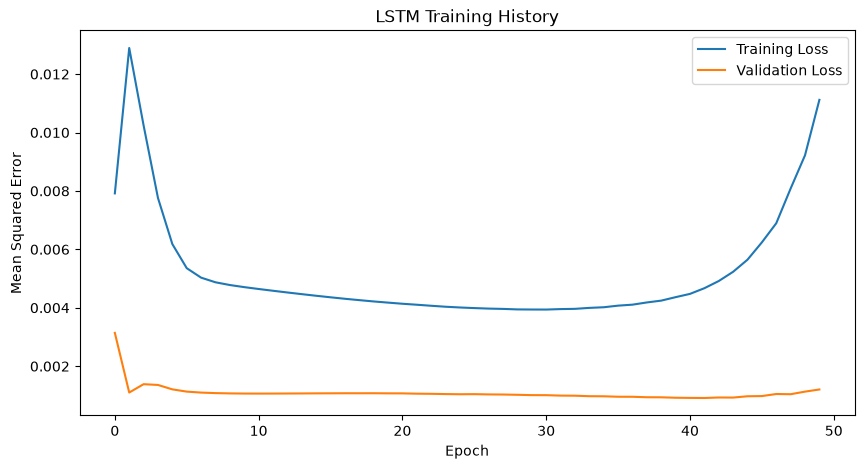

In [10]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('LSTM Training History')
plt.legend()

plt.show()

In [11]:
y_pred_scaled = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


In [12]:
y_test_actual = target_scaler.inverse_transform(y_test)
y_pred_actual = target_scaler.inverse_transform(y_pred_scaled)

In [13]:
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAPE: {mape:.2f}%")

MAE : 0.028196
RMSE: 0.034645
MAPE: 2.62%


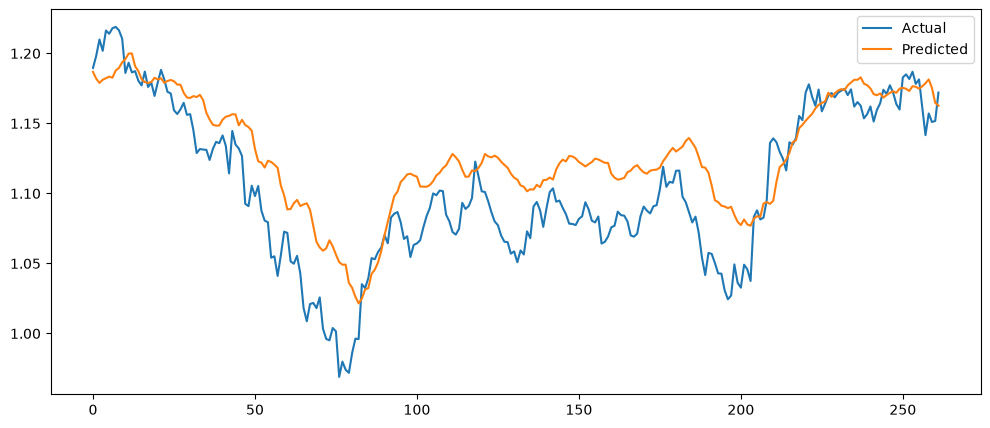

In [14]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(y_pred_actual, label="Predicted")
plt.legend()
plt.show()